# Max Flow & Fairness — Full Experiment Demo

This notebook demonstrates all experiments from the extension plan
(`max_flow_experiments_description.md`). Each section imports and runs
the `__main__` demonstration from the corresponding `example_*.py` file.

**Sections:**
1. Max Flow / Min s-t Cut Duality
2. α-Fairness Flow Optimization
3. Lagrangian Dual &amp; KKT Conditions
4. Price of Fairness &amp; Pareto Frontier
5. Visualization Catalog

In [1]:
# ── Consolidated import ──
from demo_experiments import *

print("All functions loaded. Call any demo_section*() to run.")
print("Available: demo_section1_max_flow_min_cut, demo_section2_alpha_fairness,")
print("           demo_section3_lagrangian_dual, demo_section4_price_of_fairness,")
print("           demo_section5_visualizations")

All functions loaded. Call any demo_section*() to run.
Available: demo_section1_max_flow_min_cut, demo_section2_alpha_fairness,
           demo_section3_lagrangian_dual, demo_section4_price_of_fairness,
           demo_section5_visualizations


## 1. Max Flow / Min s-t Cut Duality

**Source:** `example_max_flow_min_cut.py`

Demonstrates the Ford-Fulkerson max-flow min-cut theorem from two angles:
- **Algorithmic:** extract the min cut by BFS on the residual graph
- **LP duality:** solve both primal (max flow) and dual (min cut) LPs with CVXPY

=== Max Flow / Min Cut (Algorithmic) ===
Max flow value:       18
S-side of min cut:    {'s'}
T-side of min cut:    {'t', 'd', 'c', 'a', 'b', 'e'}
Min cut capacity:     18
Duality gap:          0.00000000

Bottleneck edges (crossing S→T, fully saturated):
  s→a: flow=10, capacity=10, SATURATED
  s→b: flow=8, capacity=8, SATURATED

=== Max Flow / Min Cut (LP Duality) ===
Primal (max flow) value: 18.000000
Dual (min cut) value:    0.000000
Duality gap:             17.99999998

Dual edge variables d_{u,v} (=1 means in the cut):


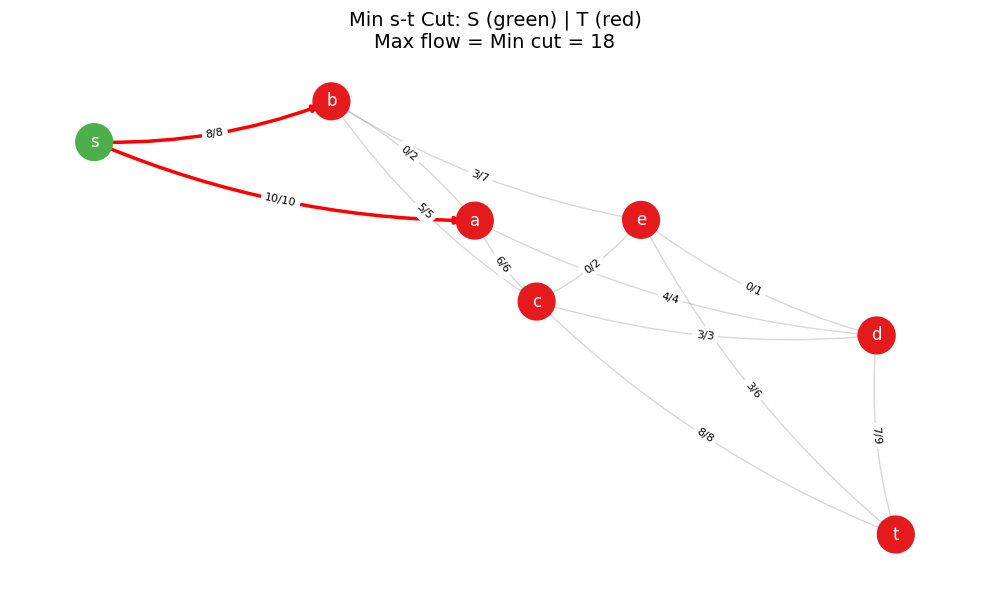

In [2]:
# ── Section 1: Max Flow / Min Cut Duality ──
demo_section1_max_flow_min_cut()

## 2. α-Fairness Flow Optimization

**Source:** `example_fairness_flow.py`

Explores the α-fairness utility family:
- α = 0 → utilitarian (standard max flow)
- α = 1 → proportional fairness / Nash bargaining
- α = 2 → harmonic mean fairness
- α → ∞ → max-min / Rawlsian fairness

Includes lexicographic max-min and comparison of edge flow distributions.

=== α-Fairness Flow Optimization ===

α=0.0 (         utilitarian): total flow = 23.0000
α=0.5 (               α=0.5): total flow = 23.0000
α=1.0 (        proportional): total flow = 23.0000
α=2.0 (               α=2.0): total flow = 22.7625
α=5.0 (               α=5.0): total flow = 22.2784

NetworkX max flow (LP):   total flow = 23.0000
Max-min fair (iterative): total flow = 23.0000
  Source edge flows: {('s', 'a'): np.float64(9.000000002249676), ('s', 'b'): np.float64(7.999999999328797), ('s', 'c'): np.float64(5.999999997409733)}


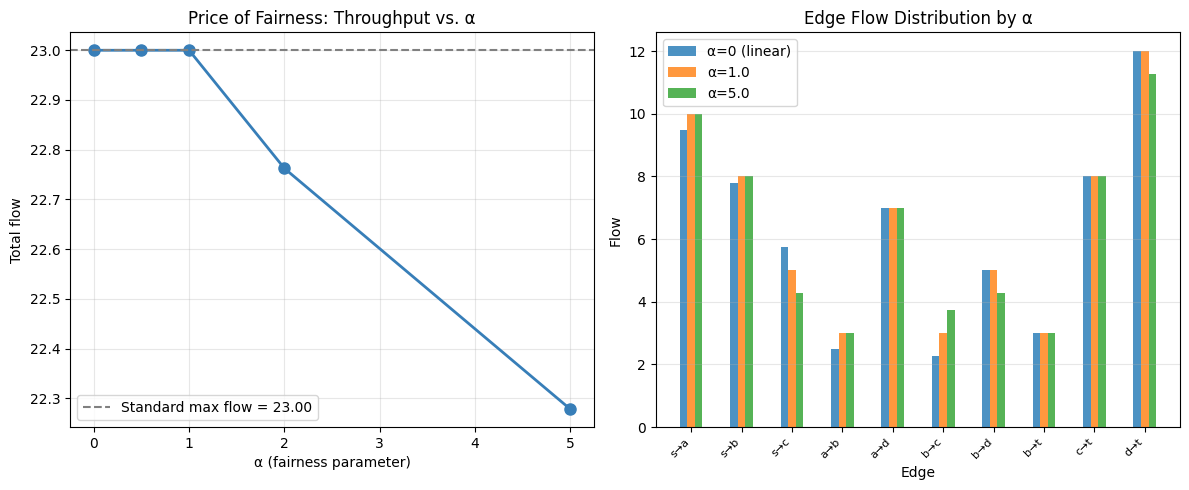


Key insight: α=0 is utilitarianism, α=1 is proportional fairness,
α→∞ approaches max-min (Rawlsian) fairness.


In [2]:
# ── Section 2: α-Fairness Flow Optimization ──
demo_section2_alpha_fairness()

## 3. Lagrangian Dual &amp; KKT Conditions

**Source:** `example_fairness_dual.py`

For the log-utility (α=1) flow problem:
- Derives the Lagrangian dual analytically
- Solves dual numerically, recovers primal flows
- Verifies complementary slackness: λ_e · (c_e − f_e) ≈ 0
- Interprets λ_e as congestion tolls, μ_u as node potentials
- Compares with standard max-flow dual (integral 0-1 solutions)

In [4]:
# ── Section 3: Lagrangian Dual & KKT Conditions ──
demo_section3_lagrangian_dual()

Primal solution (log utility, proportional fairness):
  f(s→a) = 5.0000  (capacity = 5)
  f(s→b) = 2.0000  (capacity = 3)
  f(a→t) = 4.0000  (capacity = 4)
  f(a→b) = 1.0000  (capacity = 1)
  f(b→t) = 3.0000  (capacity = 3)

Optimal log-utility value: 4.787492
=== Lagrangian Dual of Log-Fairness Flow ===

Network structure:
  Source edges: [('s', 'a'), ('s', 'b')]
  Internal edges: [('a', 'b')]
  Sink edges: [('a', 't'), ('b', 't')]

Primal optimal value:     4.787492
Dual optimal value:       -4.787492 (negated since we minimized)

--- Dual Reconstruction of Primal Flows ---
  s→a: primal f=5.0000, dual-recovered f=5.0003, λ=0.2040, a=-0.0040
  s→b: primal f=2.0000, dual-recovered f=2.0002, λ=0.0000, a=0.4999
  a→t: primal f=4.0000, dual-recovered f=4.0001, λ=0.2460, a=0.0040
  a→b: primal f=1.0000, dual-recovered f=1.0001, λ=0.4960, a=0.5039
  b→t: primal f=3.0000, dual-recovered f=3.0002, λ=0.8333, a=-0.4999

--- Complementary Slackness (λ_e · (c_e - f_e) ≈ 0) ---
  s→a: λ=0.2040, c

## 4. Price of Fairness &amp; Pareto Frontier

**Source:** `example_price_of_fairness.py`

Quantifies the efficiency-fairness trade-off:
- Price of Fairness (PoF) = (max_flow − fair_flow) / max_flow
- Jain's Fairness Index across topologies
- Pareto frontier via ε-constrained optimization
- Multi-commodity extension: two source-sink pairs sharing a bottleneck

=== Price of Fairness Across Network Topologies ===

Network                     Max Flow   α=1 Flow  PoF (%)  Jain(max)  Jain(α=1)
---------------------------------------------------------------------------
Parallel (high PoF)           102.00     102.00     0.0%     0.5200     0.5200
Mesh (moderate PoF)            23.00      23.00     0.0%     0.9616     0.9330


=== Pareto Frontier: Efficiency vs. Fairness (Mesh Network) ===

Max-flow point:       total=23.00, Jain=0.9616
Max-fair point:       total=22.08, Jain=0.9031
Price of fairness:    4.0%


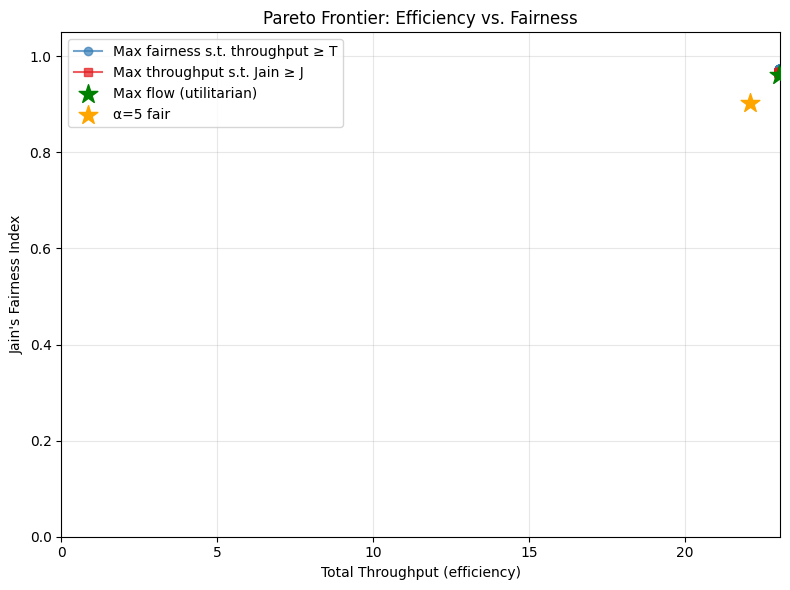


=== Multi-Commodity Fairness ===
Network: two commodities sharing a bottleneck edge a→b (capacity 8)

Utilitarian (max sum):        x1=4.00, x2=4.00, total=8.00
Proportional fair (log):      x1=4.00, x2=4.00, total=8.00
Max-min fair (egalitarian):   x1=4.00, x2=4.00, total=8.00

α-fairness sweep for multi-commodity:
  α=0.0: x1=4.00, x2=4.00, total=8.00
  α=0.5: x1=4.00, x2=4.00, total=8.00
  α=1.0: x1=4.00, x2=4.00, total=8.00
  α=2.0: x1=4.00, x2=4.00, total=8.00
  α=5.0: x1=4.00, x2=4.00, total=8.00

Key insight: With a shared bottleneck, the utilitarian solution
may starve one commodity. Fairness notions guarantee each commodity
a minimum share of the scarce capacity.
  Drag the slider to explore the fairness-efficiency trade-off in real time.


FloatSlider(value=1.0, continuous_update=False, description='α:', layout=Layout(width='80%'), max=5.0, style=S…

Output()

In [5]:
# ── Section 4: Price of Fairness & Pareto Frontier ──
demo_section4_price_of_fairness()

from example_flow_visualizations import *

print("  Drag the slider to explore the fairness-efficiency trade-off in real time.")
G, pos = demo_network()
interactive_alpha_slider(G)


## 5. Visualization Catalog

**Source:** `example_flow_visualizations.py`

Demonstrates all nine visualization functions covering:
- **Graph-centric:** edge utilization coloring, min-cut partition
- **Constraint-space:** feasible flow polytope (2D projection)
- **Duality-space:** primal-dual gap, complementary slackness heatmap
- **Fairness-space:** dashboard (bar chart + throughput curve + Jain index)
- **Temporal:** augmenting-path animation, α-sweep morphing
- **Interactive:** α slider (ipywidgets) for real-time exploration

Demo network: max flow value = 15
Flow: {('s', 'a'): 8, ('s', 'b'): 7, ('a', 'b'): 2, ('a', 'c'): 6, ('b', 'c'): 2, ('b', 'd'): 7, ('c', 't'): 8, ('d', 't'): 7}

[5a] Edge utilization visualization


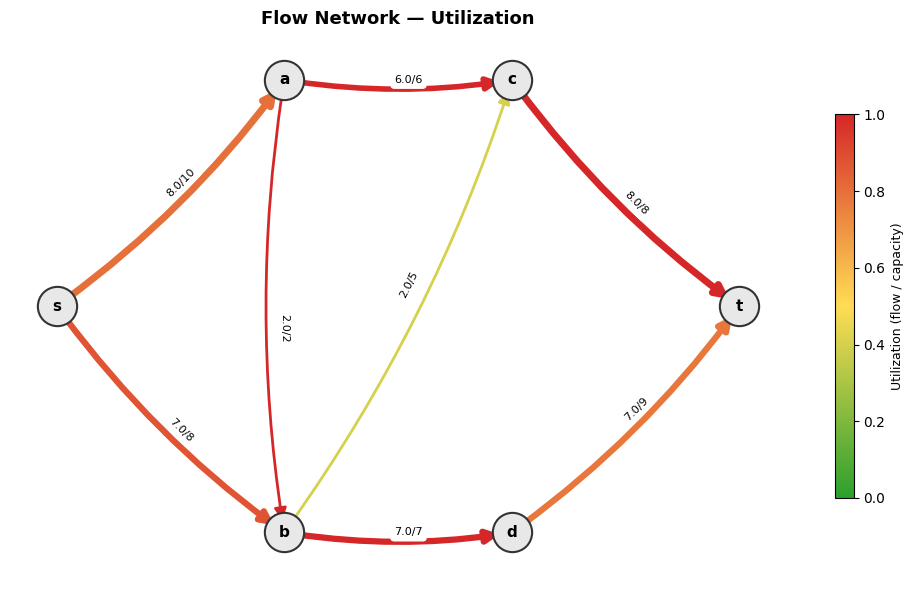


[5b] Min-cut partition
  S-side: {'c', 'a', 's', 'b'}  |  T-side: {'t', 'd'}  |  Cut edges: [('b', 'd'), ('c', 't')]


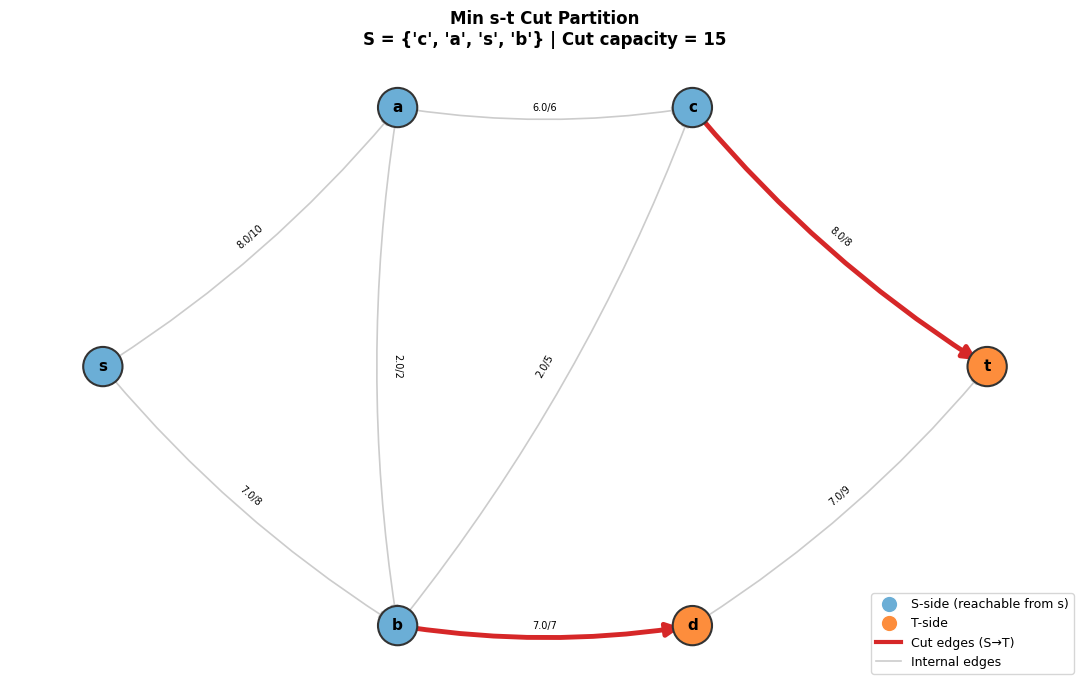


[5c] Feasible flow polytope (2D projection)


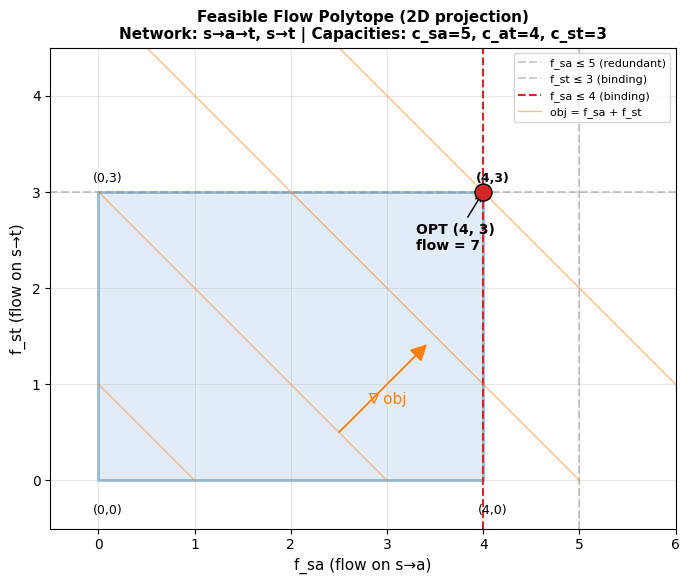


[5d] Duality gap + complementary slackness heatmap


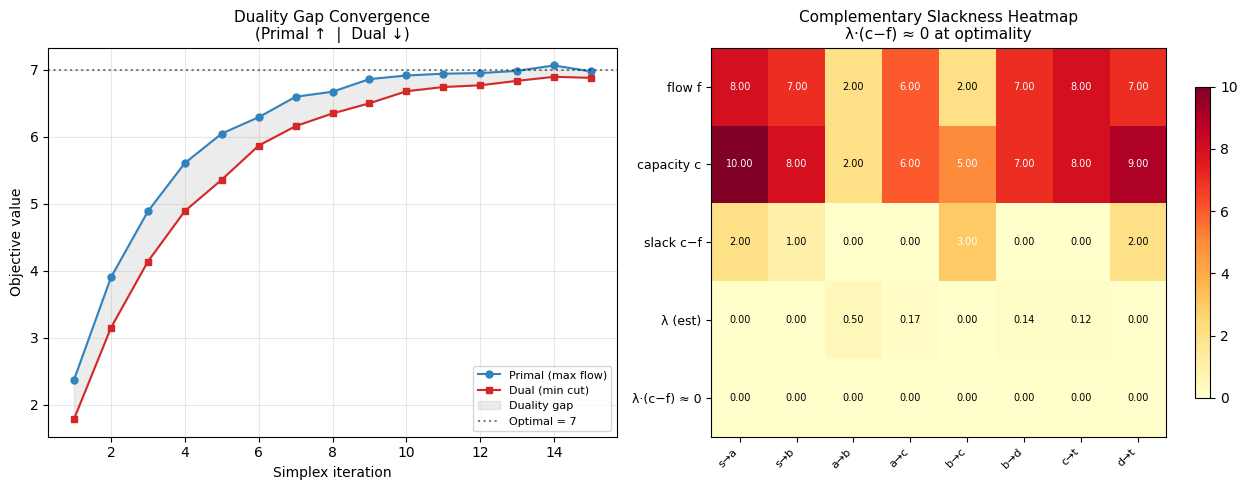


[5e] Fairness dashboard (α ∈ {0, 0.5, 1, 2, 5})


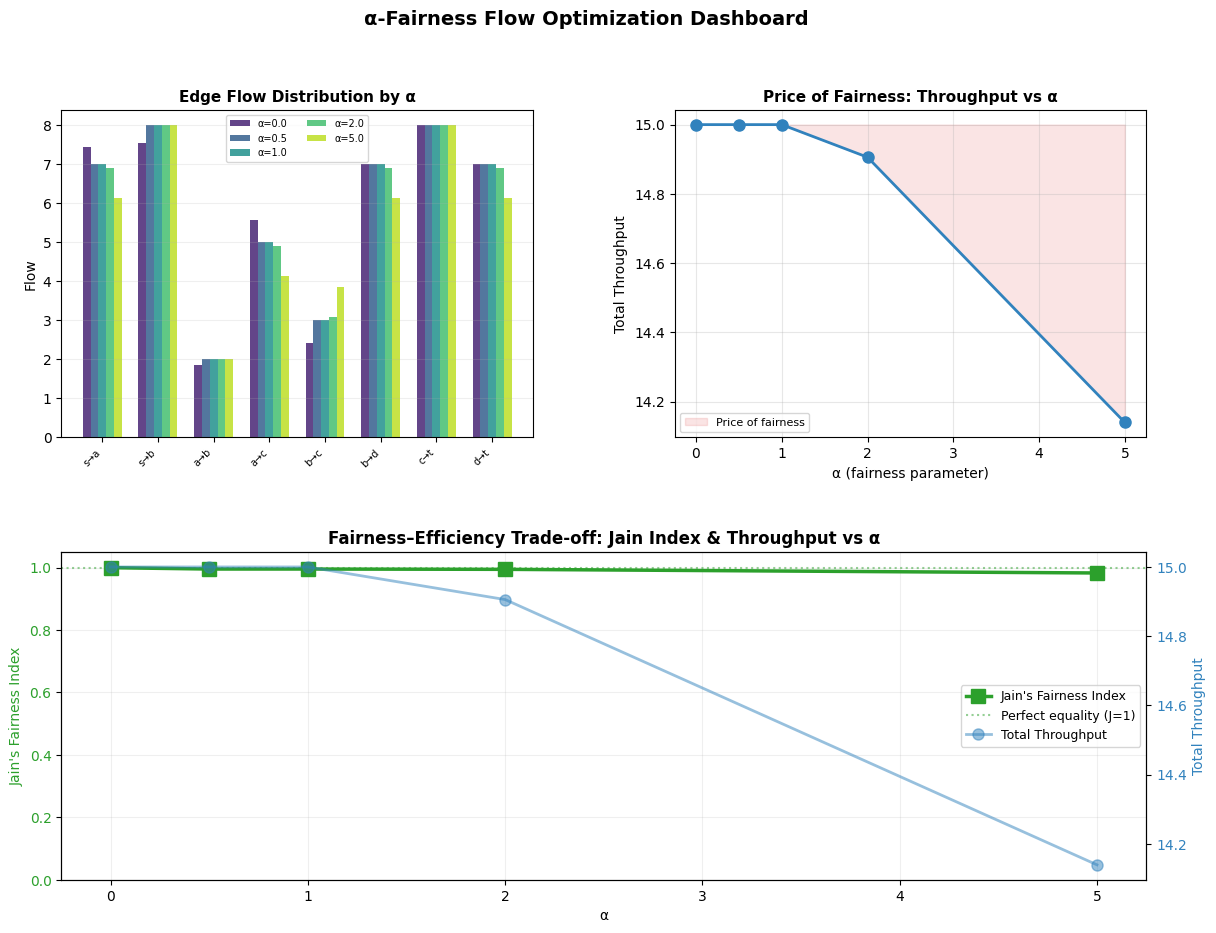


[5f] Lagrangian saddle point (3D + 2D contours)


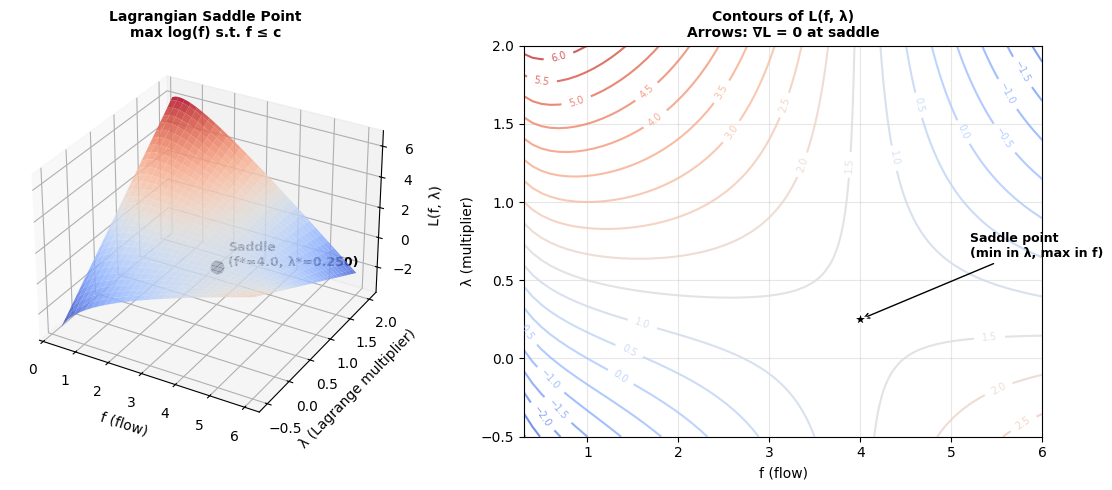


[5g] Generating augmenting-path animation...
  Animation created. Rendering as HTML...



[5h] Generating α-sweep animation (pre-computing 30 solves)...
  Animation created. Rendering...



[5i] Launching interactive α slider...
  Drag the slider to explore the fairness-efficiency trade-off in real time.


In [6]:
# ── Section 5: Visualization Catalog ──
demo_section5_visualizations()

---

## Summary of Experiments

| Section | Source File | Key Result |
|---|---|---|
| 1 | `example_max_flow_min_cut` | Max flow = Min cut capacity (algorithmic + LP duality) |
| 2 | `example_fairness_flow` | α-fairness spectrum: α=0 (utilitarian) → α=∞ (max-min) |
| 3 | `example_fairness_dual` | Lagrangian dual reveals shadow prices λ_e, node potentials μ_u |
| 4 | `example_price_of_fairness` | Price of Fairness quantified; Pareto frontier visualized |
| 5 | `example_flow_visualizations` | 10+ visualizations: graphs, polytopes, heatmaps, animations |

All experiments use **CVXPY** for convex optimization, **NetworkX** for graph algorithms,
and **Matplotlib** for visualization. The full plan is documented in `max_flow_experiments_description.md`.